# Phase 3: Baseline Models (Fashion Style Classification)

## Objective
Train a baseline, transfer-learning `ResNet50` model on the FashionStyle14 dataset (14 style classes) and establish reference performance using validation macro-F1 for model selection.

## Strategy
- Verify data splits via label distribution for `train`, `val`, and `test`.
- Load image paths/labels from the provided `train_new.csv`, `val_new.csv`, and `test_new.csv` files.
- Apply data augmentation for training and deterministic preprocessing for evaluation:
  - Train: random resized crop, horizontal flip, color jitter, normalize (ImageNet stats)
  - Val/Test: resize + center crop, normalize (ImageNet stats)
- Build label mappings (`label_to_id`, `id_to_label`) and compute optional class weights from the training set.
- Initialize `ResNet50` with ImageNet pretrained weights and replace the final `fc` layer with a 14-way classifier.
- Train with `AdamW` + `CosineAnnealingLR` and `CrossEntropyLoss` (optionally weighted).
- Use early stopping based on `val` macro-F1 and save the best checkpoint + training history.
- Reload the best checkpoint and evaluate on the `test` split with per-class metrics and confusion matrices.

## Output
- Saved best model checkpoint: `*_best.pt` (selected by val macro-F1)
- Training history JSON: `*_history.json` (loss/accuracy/macro-F1 per epoch)
- Learning curves plots for accuracy and loss (train vs val)
- Test results artifacts:
  - `*_test_predictions.csv` (saved predictions)
  - `TEST` summary metrics (macro precision/recall/F1)
  - Per-class classification report
  - Confusion matrix heatmaps (raw and row-normalized)


## Load & check Data

### Check the distribution of train, test, and validation set

   dataset/girlish/girlish_669.jpg
0          dataset/gal/gal_289.jpg
1    dataset/dressy/dressy_568.jpg
2  dataset/girlish/girlish_538.jpg
3         dataset/gal/gal_718.jpeg
4    dataset/ethnic/ethnic_631.jpg


,train,val,test
label,,,
conservative,643,138,137
dressy,629,135,134
ethnic,602,129,129
fairy,668,143,144
feminine,564,121,121
gal,668,142,143
girlish,772,166,166
kireime-casual,738,158,158
lolita,744,159,160


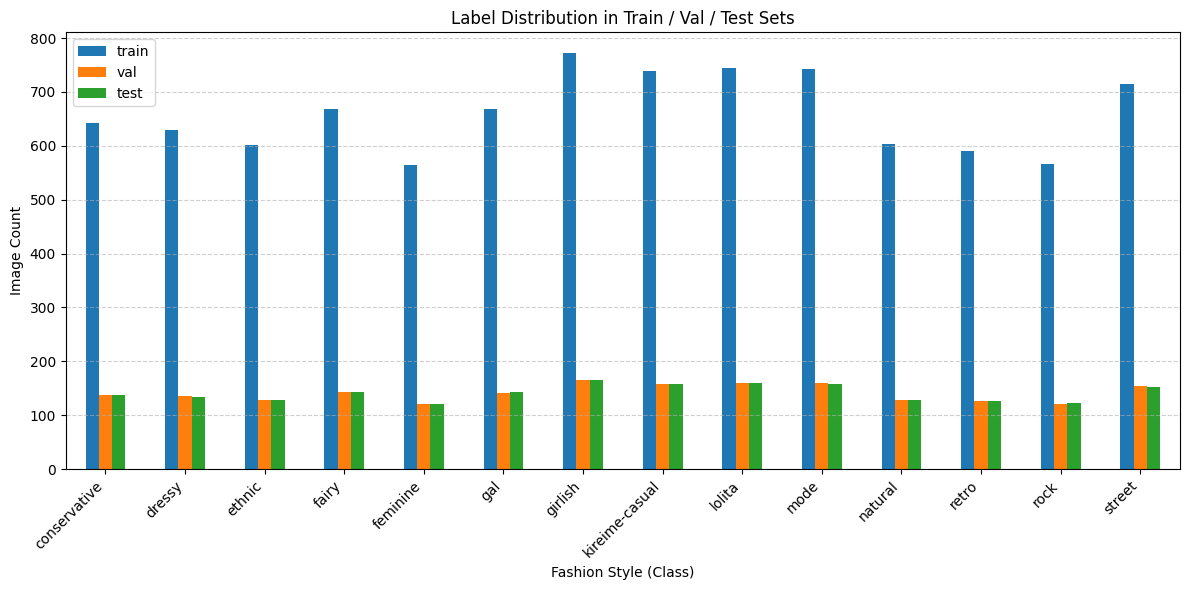

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re

# Read the fixed CSVs
base_path = Path("FashionStyle14_v1")
train_df = pd.read_csv(base_path / "train_new.csv")
val_df   = pd.read_csv(base_path / "val_new.csv")
test_df  = pd.read_csv(base_path / "test_new.csv")

# Show the first few lines to confirm column names
print(train_df.head())

# ----- Adjust if your column names differ -----
# If CSVs have only 1 column (path), and the class is part of the path like:
# dataset/kireime-casual/filename.jpg
# then extract the class from the path:

def extract_label(path):
    if pd.isna(path):
        return "unknown"
    parts = re.split(r"[\\/]+", str(path).strip())  # split on / or \
    # expected: ["dataset", "<label>", "file"]
    if len(parts) >= 3 and parts[0].lower() == "dataset":
        return parts[1]
    elif len(parts) >= 2:
        return parts[-2]   # fallback: parent folder
    return "unknown"

train_df["label"] = train_df.iloc[:,0].apply(extract_label)
val_df["label"]   = val_df.iloc[:,0].apply(extract_label)
test_df["label"]  = test_df.iloc[:,0].apply(extract_label)

# Count label frequencies
train_counts = train_df["label"].value_counts().sort_index()
val_counts   = val_df["label"].value_counts().sort_index()
test_counts  = test_df["label"].value_counts().sort_index()

# Combine into one DataFrame for plotting
dist_df = pd.DataFrame({
    "train": train_counts,
    "val": val_counts,
    "test": test_counts
}).fillna(0).astype(int)

display(dist_df)

# ----- Plot -----
dist_df.plot(kind="bar", figsize=(12,6))
plt.title("Label Distribution in Train / Val / Test Sets")
plt.xlabel("Fashion Style (Class)")
plt.ylabel("Image Count")
plt.xticks(rotation=45, ha='right')
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## Setup: Experiment name & config

In [14]:
# EXPT NAME (appears in saved files / logs)
EXPT_NAME = "baseline_resnet50"

main_path = Path("FashionStyle14_v1")
TRAIN_CSV = main_path / "train_new.csv"
VAL_CSV   = main_path / "val_new.csv"
TEST_CSV  = main_path / "test_new.csv"

# Data
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0

# Training
EPOCHS = 25
LR = 1e-4 # 3e-4
WEIGHT_DECAY = 2e-4 # 1e-4
PATIENCE = 5  # early stopping on val macro-F1
SEED = 42

# Number of classes (FashionStyle14)
NUM_CLASSES = 14

# Where to save artifacts
OUT_DIR = f"./results/{EXPT_NAME}"
print(f"Output file path:", {OUT_DIR})

Output file path: {'./results/baseline_resnet50'}


# Imports, seeding, and helpers

In [12]:
import os, random, math, json
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import f1_score, accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from tqdm.auto import tqdm

# Reproducibility
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
os.makedirs(OUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


# Load CSVs and build label mapping

In [9]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\Sandy\OneDrive\桌面\255\FusionStyle
['.DS_Store', '.git', '.gitignore', '1_Data.ipynb', '2_Captioning.ipynb', '3_Hyperparameter_tuning.ipynb', '4_Baseline_Resnet50.ipynb', '5_Text_only.ipynb', '6_Image_only.ipynb', '7_Multimodal.ipynb', 'baseline_resnet50', 'FashionStyle14_v1', 'LLaVA', 'README.md', '__MACOSX']


In [16]:
# Each CSV has a single column with POSIX paths like:
# dataset/kireime-casual/レディース.....jpg
from pathlib import PurePosixPath

def read_paths(csv_path):
    # Handles both header/no-header cases
    df = pd.read_csv(csv_path, header=None, encoding="utf-8")
    # If the first row looks like a header (contains 'path'), handle that
    if df.shape[1] == 1:
        df.columns = ["path"]
    else:
        # If there are extra columns, keep the first as path
        df = df.iloc[:, [0]]
        df.columns = ["path"]
    return df

train_df = read_paths(TRAIN_CSV)
val_df   = read_paths(VAL_CSV)
test_df  = read_paths(TEST_CSV)

# Extract label as the folder right after "dataset/"
def extract_label(p):
    parts = PurePosixPath(str(p)).parts
    # ("dataset", "girlish", "girlish_669.jpg")
    return parts[1] if len(parts) > 1 else "unknown"

train_df["label"] = train_df["path"].apply(extract_label)
val_df["label"]   = val_df["path"].apply(extract_label)
test_df["label"]  = test_df["path"].apply(extract_label)

# Build label -> id mapping from TRAIN set (sorted for stability)
labels_sorted = sorted(train_df["label"].unique())
assert len(labels_sorted) == NUM_CLASSES, f"Expected {NUM_CLASSES} classes, got {len(labels_sorted)}"
label_to_id = {lbl: i for i, lbl in enumerate(labels_sorted)}
id_to_label = {i: lbl for lbl, i in label_to_id.items()}

# Attach numeric targets
train_df["target"] = train_df["label"].map(label_to_id)
val_df["target"]   = val_df["label"].map(label_to_id)
test_df["target"]  = test_df["label"].map(label_to_id)

print("Classes:", labels_sorted)
print("Train/Val/Test sizes:", len(train_df), len(val_df), len(test_df))
train_df.head()

Classes: ['conservative', 'dressy', 'ethnic', 'fairy', 'feminine', 'gal', 'girlish', 'kireime-casual', 'lolita', 'mode', 'natural', 'retro', 'rock', 'street']
Train/Val/Test sizes: 9248 1982 1982


,path,label,target
0,dataset/girlish/girlish_669.jpg,girlish,6
1,dataset/gal/gal_289.jpg,gal,5
2,dataset/dressy/dressy_568.jpg,dressy,1
3,dataset/girlish/girlish_538.jpg,girlish,6
4,dataset/gal/gal_718.jpeg,gal,5


# Transforms & Dataset definition

In [21]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tfms = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.14)),  # 256 for 224
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class CsvImageDataset(Dataset):
    def __init__(self, df, transforms=None, root="."):
        self.paths = df["path"].tolist()
        self.targets = df["target"].tolist()
        self.transforms = transforms
        self.root = root

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        rel_path = self.paths[idx]
        # Keep filename exactly as-is (incl. %.. encodings and Unicode)
        img_path = os.path.join(self.root, rel_path)
        with Image.open(img_path) as im:
            im = im.convert("RGB")
        if self.transforms:
            im = self.transforms(im)
        target = self.targets[idx]
        return im, target, rel_path  # return path for debugging

DATA_ROOT = "FashionStyle14_v1"  # note: parent of 'dataset'
train_ds = CsvImageDataset(train_df, transforms=train_tfms, root=DATA_ROOT)
val_ds   = CsvImageDataset(val_df,   transforms=eval_tfms, root=DATA_ROOT)
test_ds  = CsvImageDataset(test_df,  transforms=eval_tfms, root=DATA_ROOT)

# Dataloaders & (optional) class weights

In [22]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)

# Optional class weighting to help minor imbalance
class_counts = train_df["target"].value_counts().sort_index().values
class_weights = (class_counts.sum() / (NUM_CLASSES * class_counts))
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)
print("Class counts:", class_counts)
print("Class weights:", class_weights.cpu().numpy())

Class counts: [643 629 602 668 564 668 773 738 744 743 603 591 567 715]
Class weights: [1.0273273  1.0501931  1.0972947  0.9888794  1.1712259  0.9888794
 0.85455555 0.89508325 0.8878648  0.8890598  1.095475   1.1177181
 1.1650289  0.9238761 ]


### ResNet50 Training

In [23]:
# Model
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, NUM_CLASSES)
model = model.to(device)

# Loss (CrossEntropy with optional weights)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer & Scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

def run_epoch(model, loader, train: bool):
    if train:
        model.train()
    else:
        model.eval()

    all_preds, all_tgts = [], []
    running_loss = 0.0

    for imgs, tgts, _ in tqdm(loader, leave=False):
        imgs = imgs.to(device, non_blocking=True)
        tgts = tgts.to(device, non_blocking=True)

        with torch.set_grad_enabled(train):
            logits = model(imgs)
            loss = criterion(logits, tgts)
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.detach().cpu().numpy())
        all_tgts.append(tgts.detach().cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_tgts  = np.concatenate(all_tgts)

    epoch_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(all_tgts, all_preds)
    macro_f1 = f1_score(all_tgts, all_preds, average="macro")
    return epoch_loss, acc, macro_f1

#### Train loop with early stopping (by val Macro-F1)

In [24]:
best_f1 = -1.0
best_path = os.path.join(OUT_DIR, f"{EXPT_NAME}_best.pt")
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc, train_f1 = run_epoch(model, train_loader, train=True)
    val_loss, val_acc, val_f1 = run_epoch(model, val_loader, train=False)
    scheduler.step()

    history.append({
        "epoch": epoch,
        "train_loss": train_loss, "train_acc": train_acc, "train_f1": train_f1,
        "val_loss": val_loss, "val_acc": val_acc, "val_f1": val_f1,
        "lr": scheduler.get_last_lr()[0],
    })

    print(f"[{epoch:02d}] "
          f"train_loss={train_loss:.4f} acc={train_acc:.4f} f1={train_f1:.4f} | "
          f"val_loss={val_loss:.4f} acc={val_acc:.4f} f1={val_f1:.4f}")

    # Early stopping on val macro-F1
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save({"model_state": model.state_dict(),
                    "label_to_id": label_to_id,
                    "id_to_label": id_to_label,
                    "config": {
                        "IMG_SIZE": IMG_SIZE, "BATCH_SIZE": BATCH_SIZE,
                        "LR": LR, "WEIGHT_DECAY": WEIGHT_DECAY,
                        "EPOCHS": EPOCHS
                    }},
                   best_path)
        stop_counter = 0
    else:
        stop_counter += 1
        if stop_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}. Best val F1 = {best_f1:.4f}")
            break

# Save training history
with open(os.path.join(OUT_DIR, f"{EXPT_NAME}_history.json"), "w") as f:
    json.dump(history, f, indent=2)
print("Best checkpoint:", best_path)

[01] train_loss=1.3609 acc=0.5610 f1=0.5604 | val_loss=0.9025 acc=0.6877 f1=0.6764


[02] train_loss=0.5997 acc=0.7979 f1=0.7973 | val_loss=0.8856 acc=0.7089 f1=0.7052


[03] train_loss=0.3573 acc=0.8793 f1=0.8800 | val_loss=0.8026 acc=0.7381 f1=0.7374


[04] train_loss=0.2337 acc=0.9252 f1=0.9258 | val_loss=0.8370 acc=0.7351 f1=0.7319


[05] train_loss=0.1756 acc=0.9436 f1=0.9443 | val_loss=0.9761 acc=0.7109 f1=0.7026


...

[20] train_loss=0.0095 acc=0.9976 f1=0.9976 | val_loss=1.0376 acc=0.7457 f1=0.7457


[21] train_loss=0.0079 acc=0.9981 f1=0.9981 | val_loss=1.0343 acc=0.7432 f1=0.7418


[22] train_loss=0.0086 acc=0.9976 f1=0.9976 | val_loss=1.0488 acc=0.7427 f1=0.7404


[23] train_loss=0.0064 acc=0.9985 f1=0.9985 | val_loss=1.0387 acc=0.7442 f1=0.7437


[24] train_loss=0.0066 acc=0.9989 f1=0.9990 | val_loss=1.0415 acc=0.7477 f1=0.7474
Early stopping at epoch 24. Best val F1 = 0.7474
Best checkpoint: ./results/baseline_resnet50\baseline_resnet50_best.pt


# Accuracy and loss curve

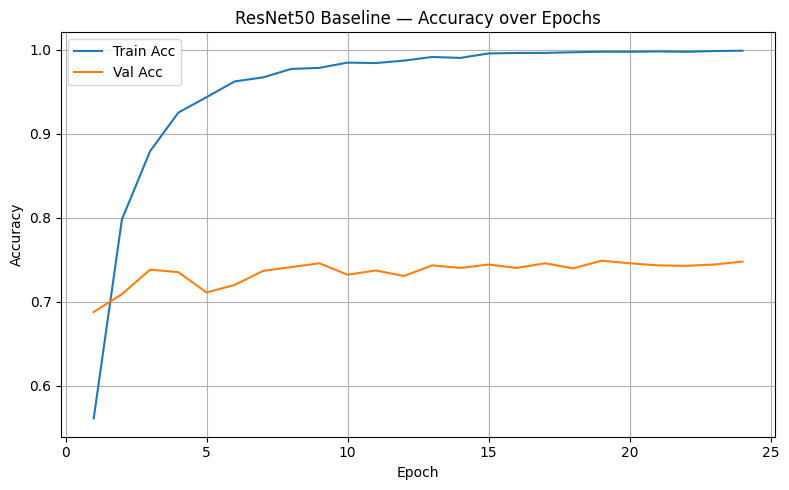

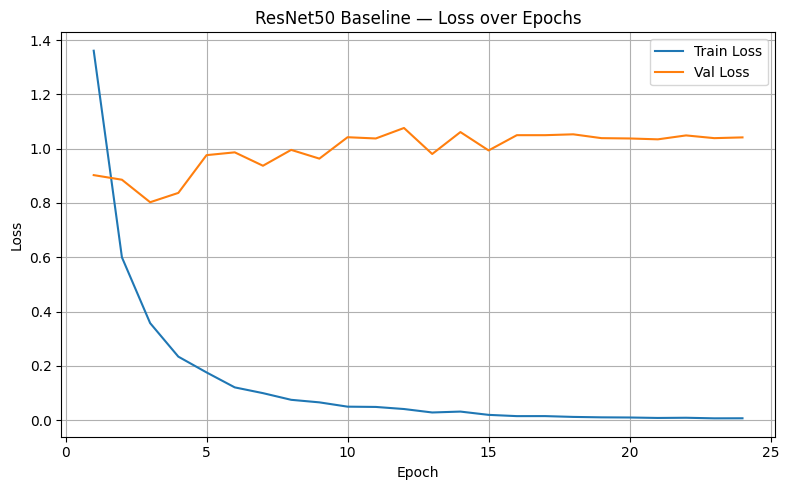

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import json

with open(".\\results\\baseline_resnet50\\baseline_resnet50_history.json", "r") as f:
    history = json.load(f)
df = pd.DataFrame(history)

# ---- Plot Accuracy ----
plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["train_acc"], label="Train Acc")
plt.plot(df["epoch"], df["val_acc"], label="Val Acc")
plt.title("ResNet50 Baseline — Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- Plot Loss ----
plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["train_loss"], label="Train Loss")
plt.plot(df["epoch"], df["val_loss"], label="Val Loss")
plt.title("ResNet50 Baseline — Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Load best model & evaluate on TEST set

In [30]:
best_path = os.path.join(OUT_DIR, f"{EXPT_NAME}_best.pt")

ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()

# 2) Save per-image predictions to CSV
def save_predictions(model, loader, split_name, out_dir=OUT_DIR):
    model.eval()
    rows = []
    with torch.inference_mode():
        for imgs, tgts, paths in tqdm(loader, desc=f"Predict {split_name}"):
            imgs = imgs.to(device, non_blocking=True)
            logits = model(imgs)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = probs.argmax(axis=1)
            tgts = tgts.numpy()
            for i in range(len(paths)):
                rec = {
                    "path": paths[i],
                    "true_id": int(tgts[i]),
                    "true_label": id_to_label[int(tgts[i])],
                    "pred_id": int(preds[i]),
                    "pred_label": id_to_label[int(preds[i])],
                    "confidence": float(probs[i, preds[i]]),
                }
                for cls_id in range(NUM_CLASSES):
                    rec[f"prob_{id_to_label[cls_id]}"] = float(probs[i, cls_id])
                rows.append(rec)
    df = pd.DataFrame(rows)
    os.makedirs(out_dir, exist_ok=True)
    out_csv = os.path.join(out_dir, f"{EXPT_NAME}_{split_name}_predictions.csv")
    df.to_csv(out_csv, index=False, encoding="utf-8-sig")
    print(f"Saved {len(df)} rows to {out_csv}")
    return df

test_df_pred = save_predictions(model, test_loader, "test")

# 3) Compute metrics from the saved dataframe
y_true = test_df_pred["true_id"].to_numpy()
y_pred = test_df_pred["pred_id"].to_numpy()


acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)

print(f"TEST — Acc: {acc:.4f} | Macro-P: {prec:.4f} | Macro-R: {rec:.4f} | Macro-F1: {f1:.4f}\n")

print("Per-class report:")
print(classification_report(
    y_true, y_pred,
    target_names=[id_to_label[i] for i in range(NUM_CLASSES)],
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=[id_to_label[i] for i in range(NUM_CLASSES)],
    columns=[id_to_label[i] for i in range(NUM_CLASSES)]
)
cm_df

Predict test: 100%|██████████| 62/62 [00:19<00:00,  3.15it/s]

Saved 1982 rows to ./results/baseline_resnet50\baseline_resnet50_test_predictions.csv
TEST — Acc: 0.7508 | Macro-P: 0.7552 | Macro-R: 0.7540 | Macro-F1: 0.7508

Per-class report:
                precision    recall  f1-score   support

  conservative       0.55      0.74      0.63       137
        dressy       0.92      0.89      0.90       134
        ethnic       0.77      0.81      0.79       129
         fairy       0.91      0.93      0.92       144
      feminine       0.66      0.80      0.72       121
           gal       0.79      0.74      0.77       143
       girlish       0.69      0.47      0.56       166
kireime-casual       0.62      0.55      0.58       158
        lolita       0.94      0.93      0.94       160
          mode       0.70      0.76      0.73       159
       natural       0.70      0.74      0.72       129
         retro       0.74      0.66      0.70       127
          rock       0.81      0.73      0.77       122
        street       0.78      0.80 

,conservative,dressy,ethnic,fairy,feminine,gal,girlish,kireime-casual,lolita,mode,natural,retro,rock,street
conservative,102,0,0,0,7,2,2,12,0,2,3,5,0,2
dressy,1,119,1,0,4,0,0,0,2,3,0,3,0,1
ethnic,0,2,104,0,0,1,2,5,2,1,8,3,0,1
fairy,0,0,0,134,3,1,0,0,3,0,1,1,0,1
feminine,5,0,0,0,97,4,11,0,0,0,3,1,0,0
gal,3,1,3,1,7,106,2,6,1,7,1,0,1,4
girlish,6,2,4,5,20,9,78,14,0,4,11,10,0,3
kireime-casual,38,0,3,1,2,3,3,87,0,8,6,1,4,2
lolita,1,0,0,6,1,1,0,0,149,0,0,2,0,0
mode,10,3,3,0,0,2,0,3,0,121,2,3,7,5


## heatmap

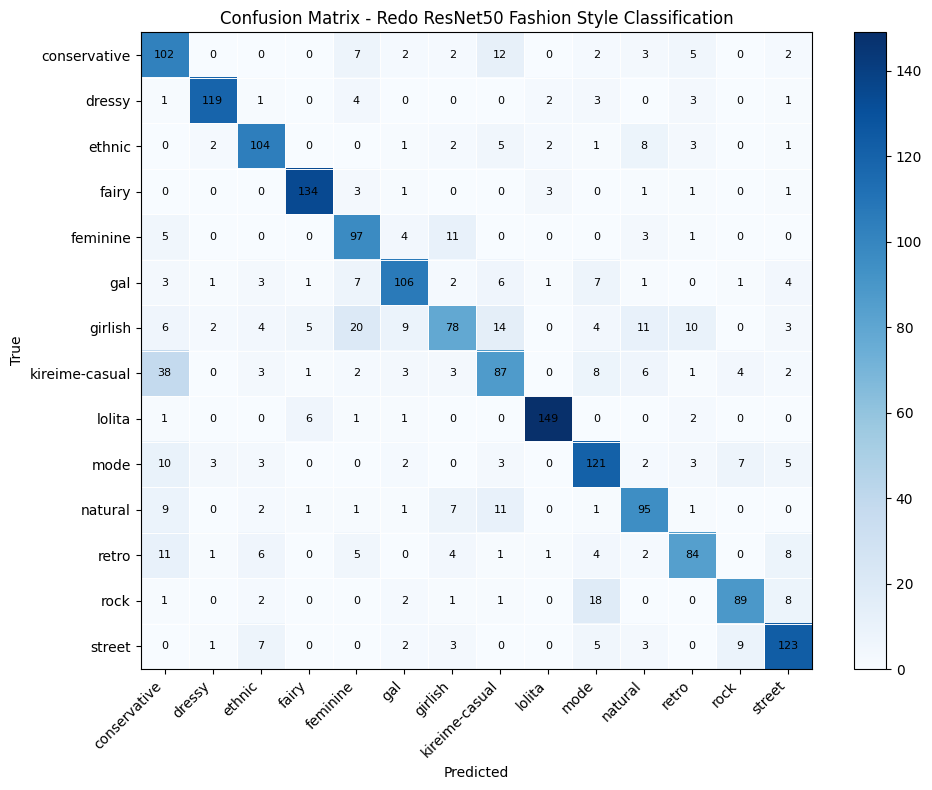

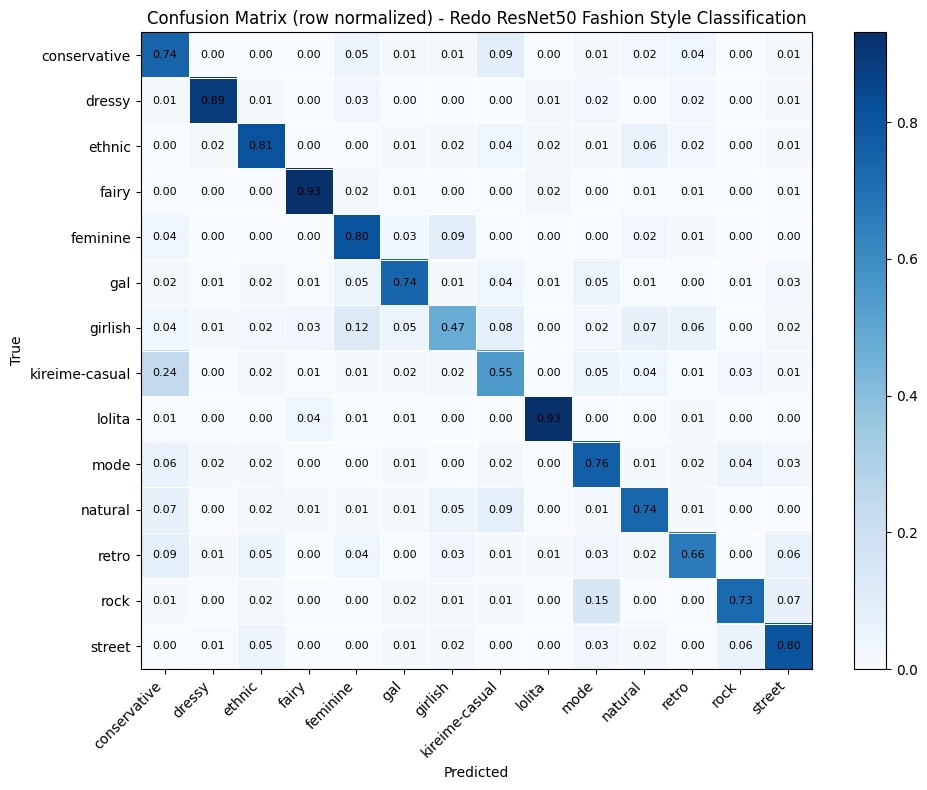

In [31]:
import numpy as np
import matplotlib.pyplot as plt

labels = list(cm_df.index)  # or your id_to_label order

def plot_heatmap_from_df(df, title="Confusion Matrix", normalize=None, annotate=True, out_path=None):
    """
    df: pandas.DataFrame confusion matrix (rows=true, cols=pred)
    normalize: None | "row" | "col"
    """
    data = df.values.astype(float)
    decimals = 0
    if normalize == "row":
        data = data / np.clip(data.sum(axis=1, keepdims=True), 1e-12, None)
        decimals = 2
    elif normalize == "col":
        data = data / np.clip(data.sum(axis=0, keepdims=True), 1e-12, None)
        decimals = 2

    C = data.shape[0]
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(data, aspect="auto", cmap="Blues")

    ax.set_xticks(range(C)); ax.set_yticks(range(C))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)

    # light grid lines (like seaborn)
    ax.set_xticks(np.arange(-.5, C, 1), minor=True)
    ax.set_yticks(np.arange(-.5, C, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.7)
    ax.tick_params(which="minor", bottom=False, left=False)

    plt.colorbar(im, ax=ax)

    if annotate:
        fmt = f"{{:.{decimals}f}}" if decimals else "{:d}"
        for i in range(C):
            for j in range(C):
                val = data[i, j]
                ax.text(j, i, fmt.format(val if decimals else int(round(val))),
                        ha="center", va="center", fontsize=8)

    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# Usage:
plot_heatmap_from_df(cm_df, title="Confusion Matrix - Redo ResNet50 Fashion Style Classification", normalize=None, annotate=True)
plot_heatmap_from_df(cm_df, title="Confusion Matrix (row normalized) - Redo ResNet50 Fashion Style Classification", normalize="row", annotate=True)
